In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)


In [4]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print(df.shape)
print(df.dtypes)
df.head(3)


(2640, 12)
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071


In [5]:
print(df.isnull().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicates")

df.drop(columns=['Source_Type'], inplace=True)


0 missing values
0 duplicates


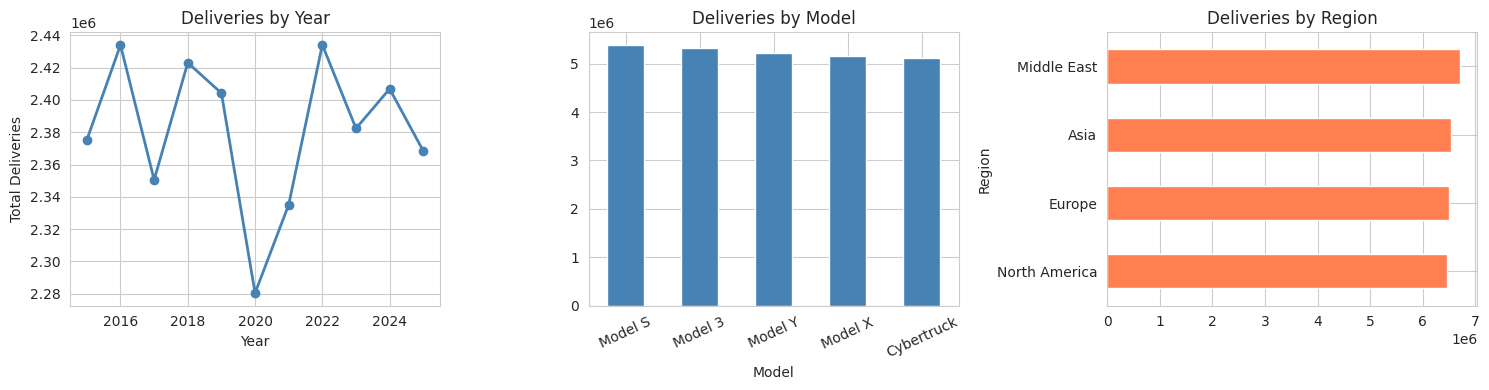

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('Year')['Estimated_Deliveries'].sum().plot(
    ax=axes[0], marker='o', color='steelblue', lw=2)
axes[0].set_title('Deliveries by Year')
axes[0].set_ylabel('Total Deliveries')

df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Deliveries by Model')
axes[1].tick_params(axis='x', rotation=25)

df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Deliveries by Region')

plt.tight_layout()
plt.show()


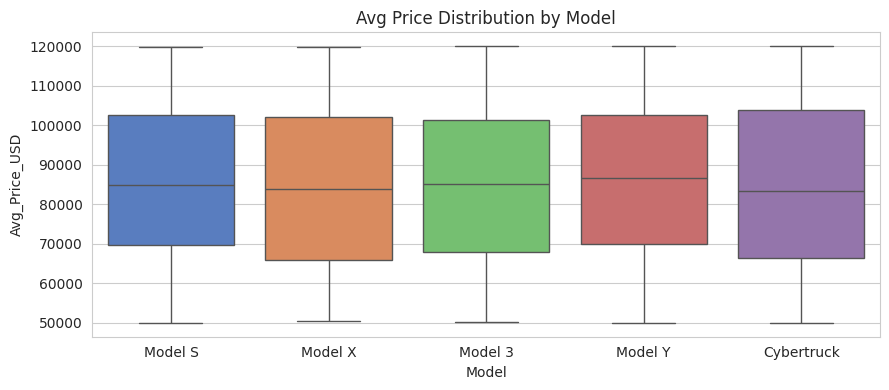

In [7]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Model', y='Avg_Price_USD', palette='muted')
plt.title('Avg Price Distribution by Model')
plt.tight_layout()
plt.show()


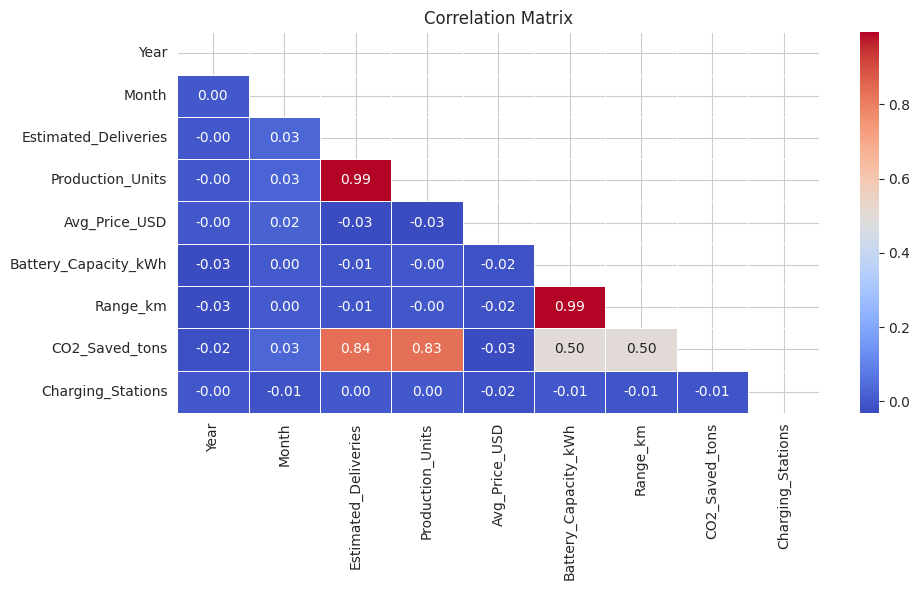

In [8]:
num = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=np.triu(np.ones(len(num), dtype=bool)), linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [9]:
df['date_ordinal'] = df['Year'] * 12 + df['Month']

df = pd.get_dummies(df, columns=['Region', 'Model'], drop_first=True)

print("Feature engineered columns added:", ['date_ordinal'])
print("OHE columns:", [c for c in df.columns if 'Region_' in c or 'Model_' in c])


Feature engineered columns added: ['date_ordinal']
OHE columns: ['Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']


In [10]:
ohe_cols = [c for c in df.columns if 'Region_' in c or 'Model_' in c]

features = [
    'Year', 'Month', 'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Charging_Stations', 'date_ordinal'
] + ohe_cols

X = df[features]
y = df['Estimated_Deliveries']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")
print(f"Features: {len(features)}")


Train: 2112  Test: 528
Features: 16


In [11]:
models = {
    'Ridge':             Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
    'Lasso':             Pipeline([('sc', StandardScaler()), ('m', Lasso(max_iter=5000))]),
    'Random Forest':     Pipeline([('sc', StandardScaler()), ('m', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
}

rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    rows.append({
        'Model': name,
        'R²':    round(r2_score(y_test, p), 4),
        'MAE':   round(mean_absolute_error(y_test, p), 1),
        'RMSE':  round(np.sqrt(mean_squared_error(y_test, p)), 1)
    })

results = pd.DataFrame(rows).sort_values('RMSE')
print(results.to_string(index=False))


            Model     R²   MAE  RMSE
Gradient Boosting 0.9908 305.5 375.8
            Lasso 0.9907 311.8 378.4
            Ridge 0.9906 312.2 378.9
    Random Forest 0.9904 301.3 383.6


In [12]:
cv_pipe = Pipeline([('sc', StandardScaler()),
                    ('m', GradientBoostingRegressor(n_estimators=100, random_state=42))])

r2_scores   = cross_val_score(cv_pipe, X, y, cv=5, scoring='r2')
rmse_scores = -cross_val_score(cv_pipe, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"5-Fold CV  R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"5-Fold CV  RMSE: {rmse_scores.mean():.1f} ± {rmse_scores.std():.1f}")


5-Fold CV  R²:   0.9897 ± 0.0009
5-Fold CV  RMSE: 399.5 ± 19.4


In [13]:
param_grid = {
    'm__n_estimators':  [100, 200, 300],
    'm__max_depth':     [2, 3, 4],
    'm__learning_rate': [0.05, 0.1, 0.2],
}

gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(random_state=42))]),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
gs.fit(X_train, y_train)

best_pred = gs.predict(X_test)

print("Best params:", gs.best_params_)
print(f"CV R²:  {gs.best_score_:.4f}")
print(f"Test R²:   {r2_score(y_test, best_pred):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, best_pred):,.0f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):,.0f}")


Best params: {'m__learning_rate': 0.2, 'm__max_depth': 4, 'm__n_estimators': 300}
CV R²:  0.9929
Test R²:   0.9948
Test MAE:  215
Test RMSE: 283


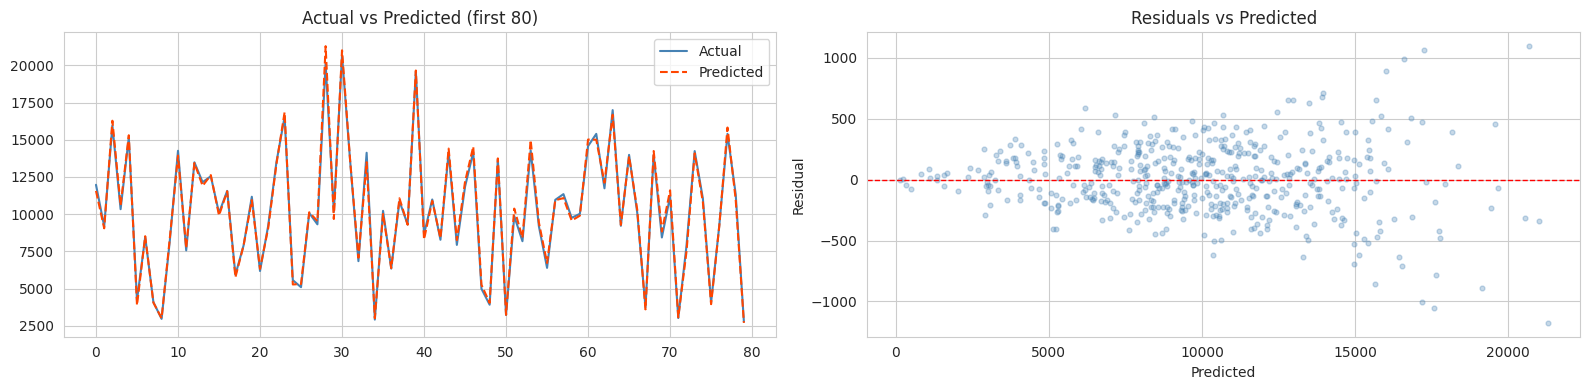

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(y_test.values[:80], label='Actual', color='steelblue', lw=1.5)
axes[0].plot(best_pred[:80], label='Predicted', color='orangered', ls='--', lw=1.5)
axes[0].set_title('Actual vs Predicted (first 80)')
axes[0].legend()

res = y_test.values - best_pred
axes[1].scatter(best_pred, res, alpha=0.3, s=12, color='steelblue')
axes[1].axhline(0, color='red', ls='--', lw=1)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


In [15]:
ts = (df.assign(date=pd.to_datetime(df[['Year','Month']].assign(day=1)))
        .groupby('date')['Estimated_Deliveries'].sum()
        .resample('QS').sum())

stat, p, *_ = adfuller(ts)
print(f"ADF p-value: {p:.4f} — {'stationary' if p < 0.05 else 'non-stationary'}")

train_ts, test_ts = ts.iloc[:-4], ts.iloc[-4:]

hw = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                          seasonal_periods=4).fit(optimized=True)
hw_fc = hw.forecast(4)

from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,0,4),
                 enforce_stationarity=False).fit(disp=False)
sarima_fc = sarima.forecast(4)

for name, fc in [('Holt-Winters', hw_fc), ('SARIMA', sarima_fc)]:
    mae  = mean_absolute_error(test_ts, fc)
    mape = (abs(test_ts.values - fc.values) / test_ts.values).mean() * 100
    print(f"{name:15s}  MAE: {mae:>10,.0f}  MAPE: {mape:.2f}%")


ADF p-value: 0.0000 — stationary
Holt-Winters     MAE:     13,735  MAPE: 2.33%
SARIMA           MAE:      5,537  MAPE: 0.92%


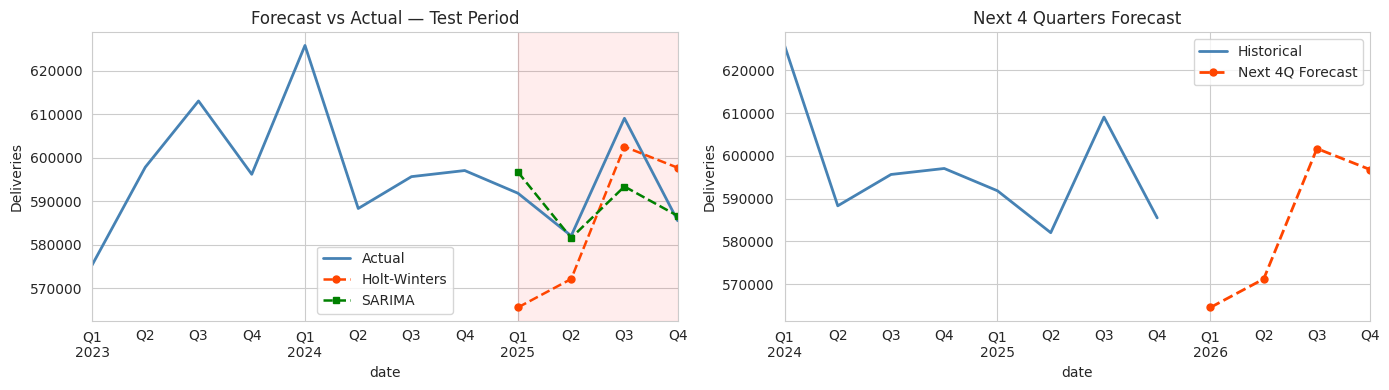

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ts.iloc[-12:].plot(ax=axes[0], label='Actual', color='steelblue', lw=2)
hw_fc.plot(ax=axes[0], label='Holt-Winters', color='orangered', ls='--', lw=1.8, marker='o', ms=5)
sarima_fc.plot(ax=axes[0], label='SARIMA', color='green', ls='--', lw=1.8, marker='s', ms=5)
axes[0].axvspan(test_ts.index[0], test_ts.index[-1], alpha=0.07, color='red')
axes[0].set_title('Forecast vs Actual — Test Period')
axes[0].set_ylabel('Deliveries')
axes[0].legend()

hw_full = ExponentialSmoothing(ts, trend='add', seasonal='add',
                               seasonal_periods=4).fit(optimized=True)
future_fc = hw_full.forecast(4)
ts.iloc[-8:].plot(ax=axes[1], label='Historical', color='steelblue', lw=2)
future_fc.plot(ax=axes[1], label='Next 4Q Forecast', color='orangered',
               ls='--', lw=2, marker='o', ms=5)
axes[1].set_title('Next 4 Quarters Forecast')
axes[1].set_ylabel('Deliveries')
axes[1].legend()

plt.tight_layout()
plt.show()


Price Model  R²:   0.9999
Price Model  MAE:  $118
Price Model  RMSE: $157


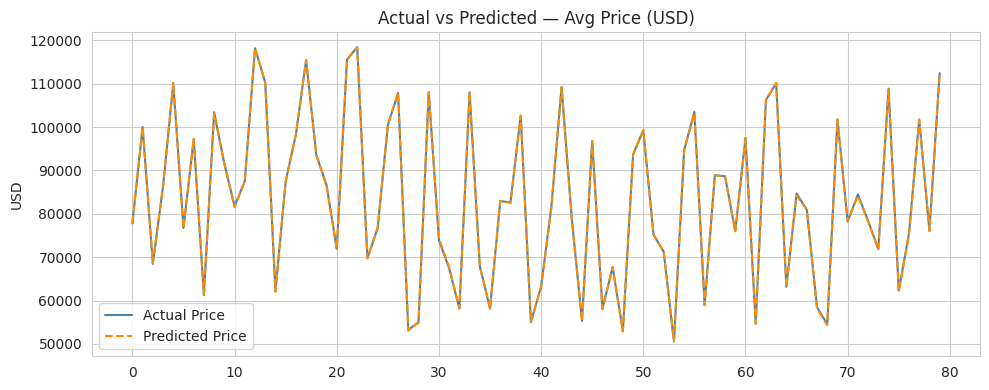

In [17]:
y_price = df['Avg_Price_USD']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X, y_price, test_size=0.2, random_state=42)

price_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('m',  GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                      learning_rate=0.1, random_state=42))
])
price_pipe.fit(Xp_train, yp_train)
pp = price_pipe.predict(Xp_test)

print(f"Price Model  R²:   {r2_score(yp_test, pp):.4f}")
print(f"Price Model  MAE:  ${mean_absolute_error(yp_test, pp):,.0f}")
print(f"Price Model  RMSE: ${np.sqrt(mean_squared_error(yp_test, pp)):,.0f}")

plt.figure(figsize=(10, 4))
plt.plot(yp_test.values[:80], label='Actual Price', color='steelblue', lw=1.5)
plt.plot(pp[:80], label='Predicted Price', color='darkorange', ls='--', lw=1.5)
plt.title('Actual vs Predicted — Avg Price (USD)')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
with open('tesla_delivery_model.pkl', 'wb') as f:
    pickle.dump(gs.best_estimator_, f)

with open('tesla_delivery_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("saved & verified ✓")
print("sample preds:", model.predict(X_test.iloc[:3]).round(0))


saved & verified ✓
sample preds: [11565.  9053. 16276.]
